# Domain-Specific Fine Tuning of Large LanguageModels for Professional Medical QA Systems  
Xuyang Zheng  
Zilong Wang

# Introduction

General-purpose models like GPT are powerful, but in healthcare they face two key issues: hallucination and lack of depth. They may generate convincing but incorrect answers, and often fail to provide clinically useful responses.

To address this, we explore parameter-efficient fine-tuning, specifically using LoRA, to adapt a lightweight model like Qwen into a more reliable and domain-specific medical assistant.

Our system focuses on two practical scenarios: initial triage and patient consultation. Instead of giving generic advice, it aims to provide structured reasoning, possible causes, and urgency assessment, helping users decide whether immediate care is needed.

From a business perspective, this approach can reduce operational costs through a 24/7 assistant, while also creating domain-specific value for applications such as telemedicine and medical compliance.

# Dataset Preview

In [61]:
import torch
import os
import numpy as np
import json

import matplotlib.pyplot as plt
from datasets import load_dataset
from typing import Optional
from dataclasses import dataclass, field
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    HfArgumentParser,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    set_seed
)
from peft import LoraConfig, TaskType, get_peft_model
from IPython.display import Image, display


DATA_PATH = "C:/Projects/ESE5971/data/train_en_1_sharegpt.jsonl"
MODEL_PATH = "C:/Projects/ESE5971/models/qwen0.5b"

In [41]:
with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = [json.loads(line) for line in f]

samples = np.random.choice(data, size=1, replace=False)

for sample in samples:
    print(sample)

{'conversations': [{'from': 'human', 'value': "If you are a doctor, please answer the medical questions based on the patient's description.\n\nI have a small, smooth red lump on my right upper arm. It is about 1cm squared in size and slightly raised. It doesnt itch and doesnt irritate. Ive had it for many years and it hasnt changed at all. Links to what it looks like are:  WWW.WWWW.WW        and         WWW.WWWW.WW"}, {'from': 'gpt', 'value': "Thanks for your question on Chat Doctor. I can understand your situation and problem. Following are the possible causes for your painless, stable upper arm lump. 1. Hematoma 2. Lipoma 3. Desmond (less likely) 4. Fibroid (less likely) Since your swelling is not causing you any trouble like not painful, not enlarging in size, non-itchy, not restricting the movements etc., no treatment is required for it. So don't worry about this swelling."}]}


# Data Preprocessing

In [42]:
def is_valid_conversation(convs):
    """
    Decoupled Check 1: Null/Empty Validation.
    """
    if not convs or len(convs) == 0:
        return False
    
    for msg in convs:
        if not str(msg.get("value", "")).strip():
            return False
    return True

def is_duplicate(convs, seen_hashes):
    """
    Decoupled Check 2: Duplicate Detection.
    """
    conv_sig = json.dumps(convs, sort_keys=True)
    if conv_sig in seen_hashes:
        return True
    
    seen_hashes.add(conv_sig)
    return False

def calculate_token_length(convs, tokenizer):
    """
    Decoupled Check 3: Token Length Calculation (ChatML format).
    """
    input_ids = []
    
    # Simulate System Prompt
    sys_prompt = "<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n"
    input_ids.extend(tokenizer.encode(sys_prompt, add_special_tokens=False))
    
    # Simulate Multi-turn Conversation
    for msg in convs:
        role = msg.get("from", "").lower()
        value = msg.get("value", "")
        
        if role in ["human", "user"]:
            text = f"<|im_start|>user\n{value}<|im_end|>\n"
        elif role in ["gpt", "assistant", "bot"]:
            text = f"<|im_start|>assistant\n{value}<|im_end|>\n"
        else:
            continue
            
        input_ids.extend(tokenizer.encode(text, add_special_tokens=False))
        
    return len(input_ids)

def plot_length_distribution(lengths):
    """
    Decoupled Task 4: Visualization.
    Generates a histogram of token lengths.
    """
    if not lengths:
        print("No data available to plot.")
        return

    # Using standard matplotlib plotting
    plt.hist(lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Labeling the axes and title
    plt.xlabel('Token Length')
    plt.ylabel('Number of Samples (Frequency)')
    plt.title('Distribution of Token Lengths')
    
    # Adding grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    

def main():
    print(f"Loading Tokenizer: {MODEL_PATH}")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast=False)
    
    print(f"Loading Dataset: {DATA_PATH}")
    dataset = load_dataset("json", data_files=DATA_PATH)["train"]
    
    lengths = []
    seen_hashes = set()
    
    # Statistics counters
    total_initial = len(dataset)
    empty_count = 0
    duplicate_count = 0

    print("Starting decoupled preprocessing and analysis...")
    
    for example in dataset:
        convs = example.get("conversations", [])
        
        if not is_valid_conversation(convs):
            empty_count += 1
            continue
            
        if is_duplicate(convs, seen_hashes):
            duplicate_count += 1
            continue
            
        token_len = calculate_token_length(convs, tokenizer)
        lengths.append(token_len)

    # Plot Data Distribution
    plot_length_distribution(lengths)

    # ================= Final Report =================
    lengths_np = np.array(lengths)
    print("\n=============== Data Analysis Report ===============")
    print(f"Initial Total:      {total_initial} samples")
    print(f"Empty/Invalid:      {empty_count} samples")
    print(f"Duplicates:         {duplicate_count} samples")
    print(f"Final Valid Total:  {len(lengths)} samples")
    print("-" * 45)
    if len(lengths_np) > 0:
        print(f"Min Length:         {np.min(lengths_np)} tokens")
        print(f"Max Length:         {np.max(lengths_np)} tokens")
        print(f"Mean Length:        {np.mean(lengths_np):.2f} tokens")
        print(f"95th Percentile:    {np.percentile(lengths_np, 95):.0f} tokens")
    print("======================================================\n")

Loading Tokenizer: C:/Projects/ESE5971/models/qwen0.5b
Loading Dataset: C:/Projects/ESE5971/data/train_en_1_sharegpt.jsonl
Starting decoupled preprocessing and analysis...


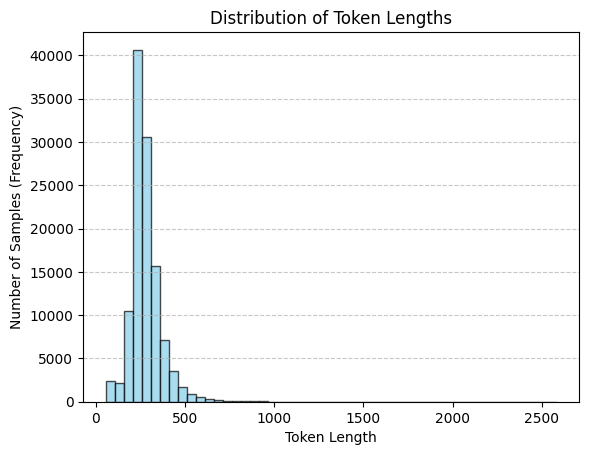


=============== Data Analysis Report ===============
Initial Total:      116617 samples
Empty/Invalid:      0 samples
Duplicates:         0 samples
Final Valid Total:  116617 samples
---------------------------------------------
Min Length:         55 tokens
Max Length:         2583 tokens
Mean Length:        276.35 tokens
95th Percentile:    430 tokens



In [43]:
main()

# How Tokens Looks Like

In [44]:
sample = {
    "conversations": [
        {
            "from": "human",
            "value": "Hi, how are you?"
        },
        {
            "from": "gpt",
            "value": "Hi I'm good! How can I help you?"
        }
    ]
}

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    use_fast=False
)

def build_input(convs, tokenizer):
    input_ids = []

    # system prompt
    sys_prompt = "<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n"
    input_ids.extend(tokenizer.encode(sys_prompt, add_special_tokens=False))

    for msg in convs:
        role = msg["from"]
        value = msg["value"]

        if role in ["human", "user"]:
            text = f"<|im_start|>user\n{value}<|im_end|>\n"
        else:
            text = f"<|im_start|>assistant\n{value}<|im_end|>\n"

        input_ids.extend(tokenizer.encode(text, add_special_tokens=False))

    return input_ids

input_ids = build_input(sample["conversations"], tokenizer)

tokens = tokenizer.convert_ids_to_tokens(input_ids)

for i in range(30):
    print(input_ids[i], tokens[i])
print("Token length:", len(input_ids))

151644 <|im_start|>
8948 system
198 Ċ
2610 You
525 Ġare
264 Ġa
10950 Ġhelpful
17847 Ġassistant
13 .
151645 <|im_end|>
198 Ċ
151644 <|im_start|>
872 user
198 Ċ
13048 Hi
11 ,
1246 Ġhow
525 Ġare
498 Ġyou
30 ?
151645 <|im_end|>
198 Ċ
151644 <|im_start|>
77091 assistant
198 Ċ
13048 Hi
358 ĠI
2776 'm
1661 Ġgood
0 !
Token length: 38


# Model Update

## Fine Tuning Parameters

In [45]:
@dataclass
class ScriptArguments:
    model_name_or_path: str = field(
        metadata={"help": "Local model directory"}
    )

    data_path: str = field(
        metadata={"help": "Local dataset directory"}
    )

    max_train_samples: Optional[int] = field(
        default = None,
        metadata = {"help": "Number of data you want to use for training"}
    )

    lora_rank: int = field(
        default=16, 
        metadata={"help": "Rank of the LoRA"}
    )

    lora_alpha: int = field(
        default=32, 
        metadata={"help": "LoRA alpha parameter"}
    )

    lora_dropout: float = field(
        default = 0.05,
        metadata = {"help": "LoRA dropout probability"}
    )

    max_seq_length: int = field(
        default=512, 
        metadata={"help": "Maximum model context length. Suggested: 8192, 4096, 2048, 1024, 512"}
    )

# LoRA

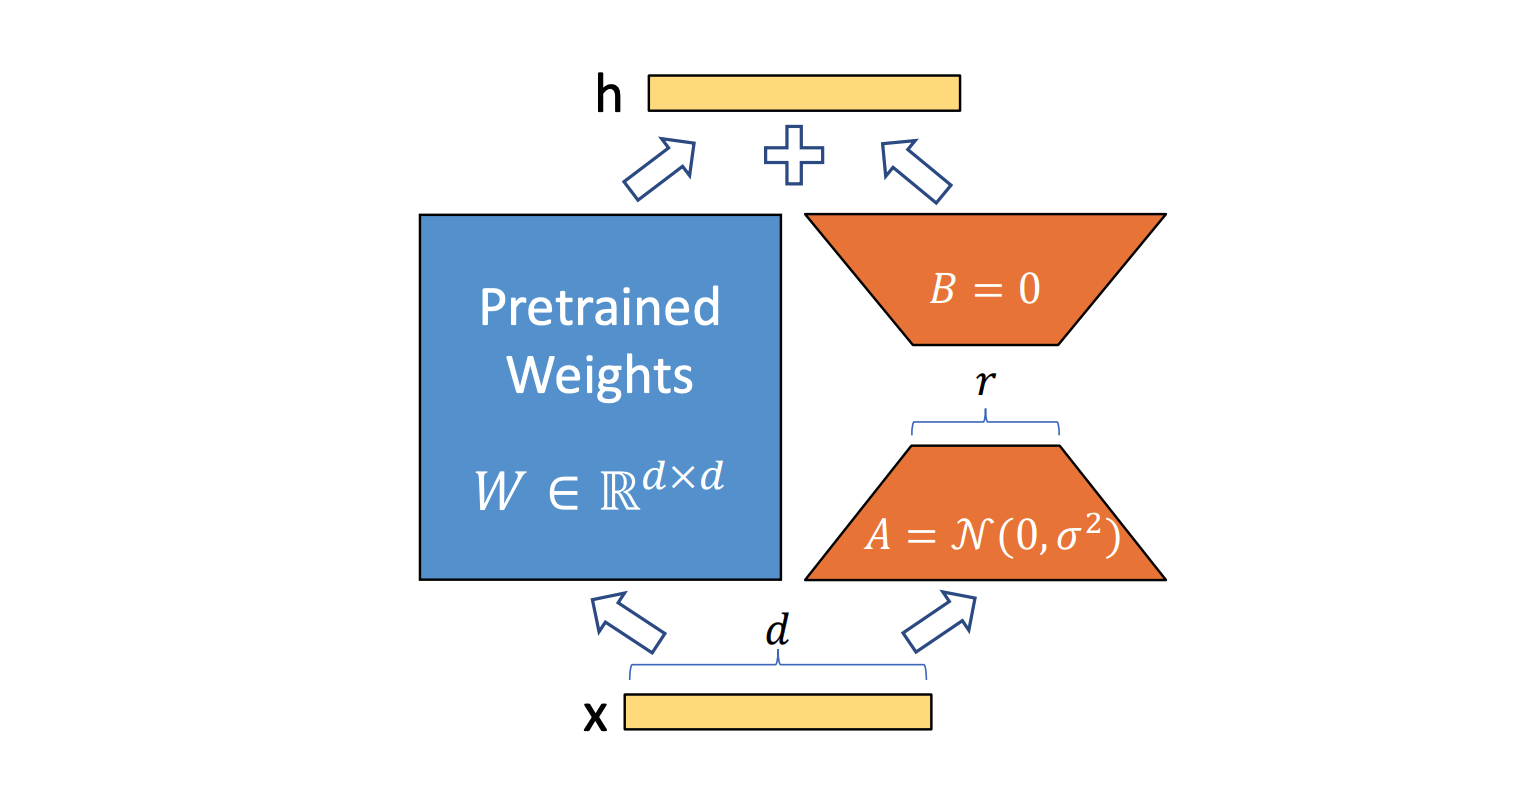

In [62]:
display(Image(filename="C:/Projects/ESE5971/reports/lora.png"))

x: Input (tokens)
d: Hidden Dimention  
W: Original weighted matrix  
A,B: two trainable matrices with shapes 𝑟×𝑑 and 𝑑×𝑟, whose product BA forms a low-rank update to the original weight.

## Training Script

In [56]:
DATA_PATH = "C:/Projects/ESE5971/data/train_en_1_sharegpt.jsonl"
MODEL_PATH = "C:/Projects/ESE5971/models/qwen0.5b"

def main():
    parser = HfArgumentParser((ScriptArguments, TrainingArguments))
    script_args, training_args = parser.parse_json_file("C:/Projects/ESE5971/config.json")

    script_args.model_name_or_path = MODEL_PATH
    script_args.data_path = DATA_PATH
    
    set_seed(training_args.seed)
    IGNORE_INDEX = -100 # Ignore non-answering part when calculating loss

    print(f"Initializing Training | Model: {script_args.model_name_or_path}")

    # ================= Loading Tokenizer (Qwen + ChatML) =================
    tokenizer = AutoTokenizer.from_pretrained(script_args.model_name_or_path, use_fast=False)
    
    # EOS token: <|im_end|>
    # Find id of pad token 
    if tokenizer.pad_token is None or tokenizer.pad_token_id is None:
        tokenizer.pad_token = "<|im_end|>"
        tokenizer.pad_token_id = tokenizer.convert_tokens_to_ids("<|im_end|>")
        if tokenizer.pad_token_id is None: # backtrack to eos_token if id not obtained
            tokenizer.pad_token_id = tokenizer.eos_token_id
            
    tokenizer.padding_side = "right"

    # ================= Preprocessing ShareGPT Dataset =================
    full_dataset = load_dataset("json", data_files=script_args.data_path)["train"]

    # Triggering Shuffle Logic when max_train_samples is set
    if getattr(script_args, "max_train_samples", None) is not None:
        if len(full_dataset) > script_args.max_train_samples:
            print(f"Original sample amount ({len(full_dataset)}) excess limit ({script_args.max_train_samples})")
            print("Shuffling samples...")
            full_dataset = full_dataset.shuffle(seed=42).select(range(script_args.max_train_samples))
            print(f"Sampling finished! Now we have: {len(full_dataset)} samples.")

    # Train Test Split
    split_dataset = full_dataset.train_test_split(test_size = 0.1, seed = 42)
    raw_train = split_dataset["train"]
    raw_eval = split_dataset["test"]
    
    def preprocess_sharegpt(examples):
        input_ids_list, labels_list = [], []
        
        for conversations in examples["conversations"]:
            input_ids, labels = [], []
            
            # Plug in system prompt
            sys_prompt = "<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n"
            sys_ids = tokenizer.encode(sys_prompt, add_special_tokens=False)
            input_ids.extend(sys_ids)
            labels.extend([IGNORE_INDEX] * len(sys_ids)) # System Prompt not participate in Loss calculation

            # Iterate 'conversations' among the dataset
            for msg in conversations:
                role = msg.get("from", "")
                value = msg.get("value", "")

                if role in ["human", "user"]:
                    text = f"<|im_start|>user\n{value}<|im_end|>\n"
                    ids = tokenizer.encode(text, add_special_tokens=False)
                    input_ids.extend(ids)
                    labels.extend([IGNORE_INDEX] * len(ids))

                elif role in ["assistant", "gpt"]:
                    text = f"<|im_start|>assistant\n{value}<|im_end|>\n"
                    ids = tokenizer.encode(text, add_special_tokens=False)
                    input_ids.extend(ids)
                    labels.extend(ids)

            # Truncating Logic
            if len(input_ids) > script_args.max_seq_length:
                input_ids = input_ids[:script_args.max_seq_length]
                labels = labels[:script_args.max_seq_length]

            input_ids_list.append(input_ids)
            labels_list.append(labels)

        return {"input_ids": input_ids_list, "labels": labels_list}

    print("Analysing ShareGPT dataset...")
    tokenized_train = raw_train.map(
        preprocess_sharegpt, 
        batched=True, 
        remove_columns=raw_train.column_names,
        desc="Tokenizing ShareGPT"
    )

    tokenized_eval = raw_eval.map(
        preprocess_sharegpt,
        batched = True,
        remove_columns=raw_eval.column_names   
    )

    # ================= Load Model =================
    model = AutoModelForCausalLM.from_pretrained(
        script_args.model_name_or_path,
        device_map="auto",
        torch_dtype=torch.bfloat16 if training_args.bf16 else torch.float16
    )
    model.config.use_cache = False 

    # ================= Load LoRA =================
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
    peft_config = LoraConfig(
        task_type = TaskType.CAUSAL_LM,
        r = script_args.lora_rank,
        lora_alpha = script_args.lora_alpha,
        lora_dropout = script_args.lora_dropout,
        target_modules = target_modules
    )
    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()

    # ================= Train =================
    data_collator = DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=model,
        label_pad_token_id=IGNORE_INDEX,
        padding=True
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset = tokenized_eval,
        processing_class=tokenizer,
        data_collator=data_collator,
    )

    print("Start Training...")
    trainer.train()
    trainer.save_model(training_args.output_dir)

    print(f"Training Completed")

    # ================= Plot Loss Curve =================
    log_history = trainer.state.log_history
    
    train_steps = []
    train_losses = []
    eval_steps = []
    eval_losses = []
    
    for log in log_history:
        if "loss" in log and "eval_loss" not in log:
            train_steps.append(log["step"])
            train_losses.append(log["loss"])
        if "eval_loss" in log:
            eval_steps.append(log["step"])
            eval_losses.append(log["eval_loss"])
    
    print("Train logs:", list(zip(train_steps, train_losses)))
    print("Eval logs:", list(zip(eval_steps, eval_losses)))
    
    plt.figure(figsize=(8, 5))
    if train_steps:
        plt.plot(train_steps, train_losses, marker="o", label="Train Loss")
    if eval_steps:
        plt.plot(eval_steps, eval_losses, marker="s", label="Eval Loss")
    
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Training / Evaluation Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

Initializing Training | Model: C:/Projects/ESE5971/models/qwen0.5b
Original sample amount (116617) excess limit (200)
Shuffling samples...
Sampling finished! Now we have: 200 samples.
Analysing ShareGPT dataset...


Loading weights: 100%|██████████████████████████████████████████████████████████████| 290/290 [00:00<00:00, 378.70it/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


trainable params: 4,399,104 || all params: 498,431,872 || trainable%: 0.8826
Start Training...


Step,Training Loss,Validation Loss
20,2.580230,2.815914
40,2.226181,2.757663
60,2.670486,2.744976
80,2.764973,2.739842
100,2.694882,2.734070
120,2.752584,2.729256
140,2.560896,2.724985
160,2.660888,2.725192
180,2.068596,2.723869


Training Completed
Train logs: [(1, 3.733154058456421), (10, 2.624690161810981), (20, 2.5802303314208985), (30, 2.356393051147461), (40, 2.226180648803711), (50, 2.2609956741333006), (60, 2.670486259460449), (70, 2.6477687835693358), (80, 2.7649730682373046), (90, 2.7096717834472654), (100, 2.6948820114135743), (110, 2.585714340209961), (120, 2.752583885192871), (130, 2.3511085510253906), (140, 2.5608959197998047), (150, 2.5404617309570314), (160, 2.66088752746582), (170, 2.326201057434082), (180, 2.0685955047607423)]
Eval logs: [(20, 2.815913677215576), (40, 2.7576630115509033), (60, 2.7449755668640137), (80, 2.7398416996002197), (100, 2.73406982421875), (120, 2.7292561531066895), (140, 2.724984645843506), (160, 2.7251923084259033), (180, 2.7238688468933105)]


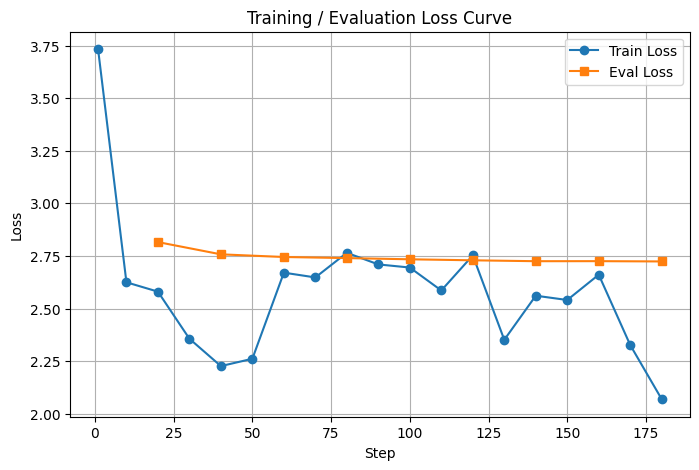

In [57]:
main()

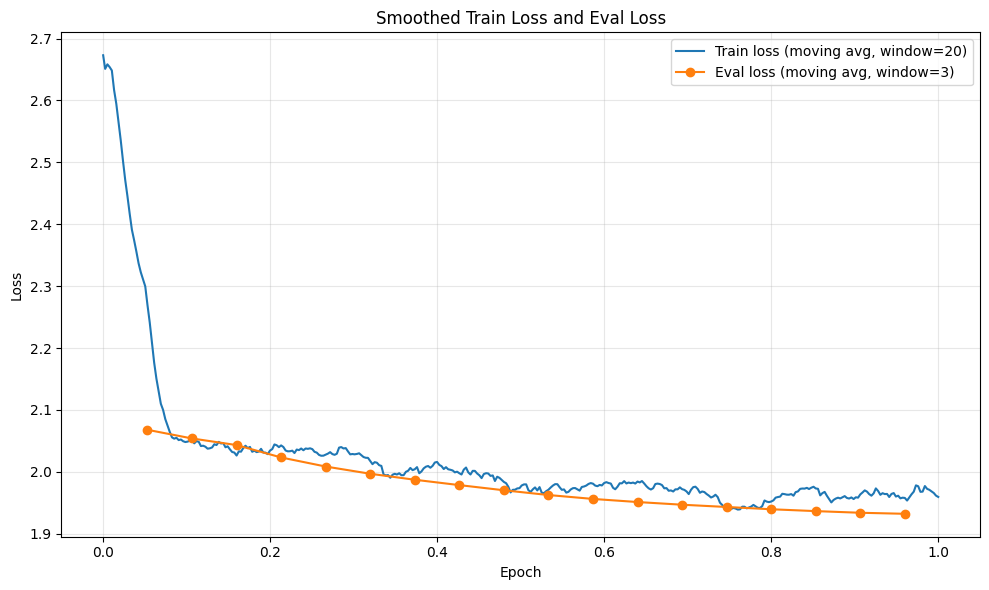

In [60]:
display(Image(filename="C:/Projects/ESE5971/outputs/output.png"))

# Next Steps

- Tuning LoRA hyperparameters  
- Try different LoRA target modules  
- More evaluation metrics
- Explore reinforcement learning methods (RLHF, DPO, PPO, etc.) to further align the model outputs